In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

import random

from SQUIC_functions import *

In [2]:
DATASET = "../datasets/AMLSimData/1_1K"

accounts = pd.read_csv(f'{DATASET}/accounts.csv')
transactions = pd.read_csv(f'{DATASET}/transactions.csv')

In [3]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [4]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]
    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount
        # elif tx_type == 'DEPOSIT':
        #    new_balance = last_balance + amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount
        # elif tx_type == 'WITHDRAWAL':
        #     new_balance = last_balance - amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})

In [5]:
len(balances)

1000

In [6]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}, {'date': 7, 'balance': 202.04}, {'date': 15, 'balance': 17.6}, {'date': 17, 'balance': 35.2}, {'date': 18, 'balance': 52.8}, {'date': 26, 'balance': 70.4}, {'date': 33, 'balance': -114.04}, {'date': 36, 'balance': -298.48}, {'date': 37, 'balance': -280.88}, {'date': 45, 'balance': -465.32}, {'date': 46, 'balance': -447.72}, {'date': 53, 'balance': -632.16}, {'date': 55, 'balance': -816.6}, {'date': 58, 'balance': -799.0}, {'date': 64, 'balance': -983.44}, {'date': 67, 'balance': -965.84}, {'date': 69, 'balance': -948.24}, {'date': 72, 'balance': -1132.68}, {'date': 76, 'balance': -1317.12}, {'date': 78, 'balance': -1299.52}, {'date': 86, 'balance': -1281.92}, {'date': 99, 'balance': -1264.32}, {'date': 105, 'balance': -1448.76}, {'date': 106, 'balance': -1431.16}, {'date': 108, 'balance': -1413.56}, {'date': 112, 'balance': -1598.0}, {'date': 116, 'balance': -1580.4}, {'date': 119, 'balance': -1562.8}, {'date': 125, 'balance': -1747.24}, {'date': 134,

In [7]:
import os
import json

file_path = "../datasets/json/1K.json"

# Otherwise, process your raw dataset and save
with open(file_path, "w") as f:
        json.dump(balances, f)


In [7]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [8]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,0.01,151.13,140.49,178.38,240.20,147.66,158.34,...,1970.87,2003.49,2021.47,1035.51,228.15,505.04,232.48,433.74,733.72,414.21
1,184.44,175.80,142.06,-125.87,151.13,140.49,178.38,240.20,147.66,158.34,...,3906.09,4247.91,3456.31,2473.23,629.74,863.83,277.24,697.62,1380.83,520.12
2,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,6453.45,7247.03,5578.29,4370.97,261.70,883.60,304.16,1307.15,1805.36,866.03
3,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,9015.04,10664.13,6756.00,5978.22,974.83,921.38,131.35,1516.45,2628.90,1610.57
4,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,11674.79,14435.14,9031.86,7597.62,1856.49,1098.21,618.02,1903.67,3546.84,698.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2459.42,-425.25,-3324.70,...,11097918.04,12089534.68,14601036.72,34797516.99,9492793.06,10375104.27,13883185.18,21491333.73,14277318.48,19663746.89
196,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2329.10,-425.25,-3324.70,...,11100682.32,12092694.17,14603000.41,34798617.05,9493690.94,10375317.70,13883494.04,21491715.32,18981127.13,28210785.13
197,-2967.92,5052727.53,-2698.94,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11103791.12,12096145.37,25520923.82,34800442.38,9494511.40,10375612.51,15319097.36,21492112.69,25189362.25,32950725.75


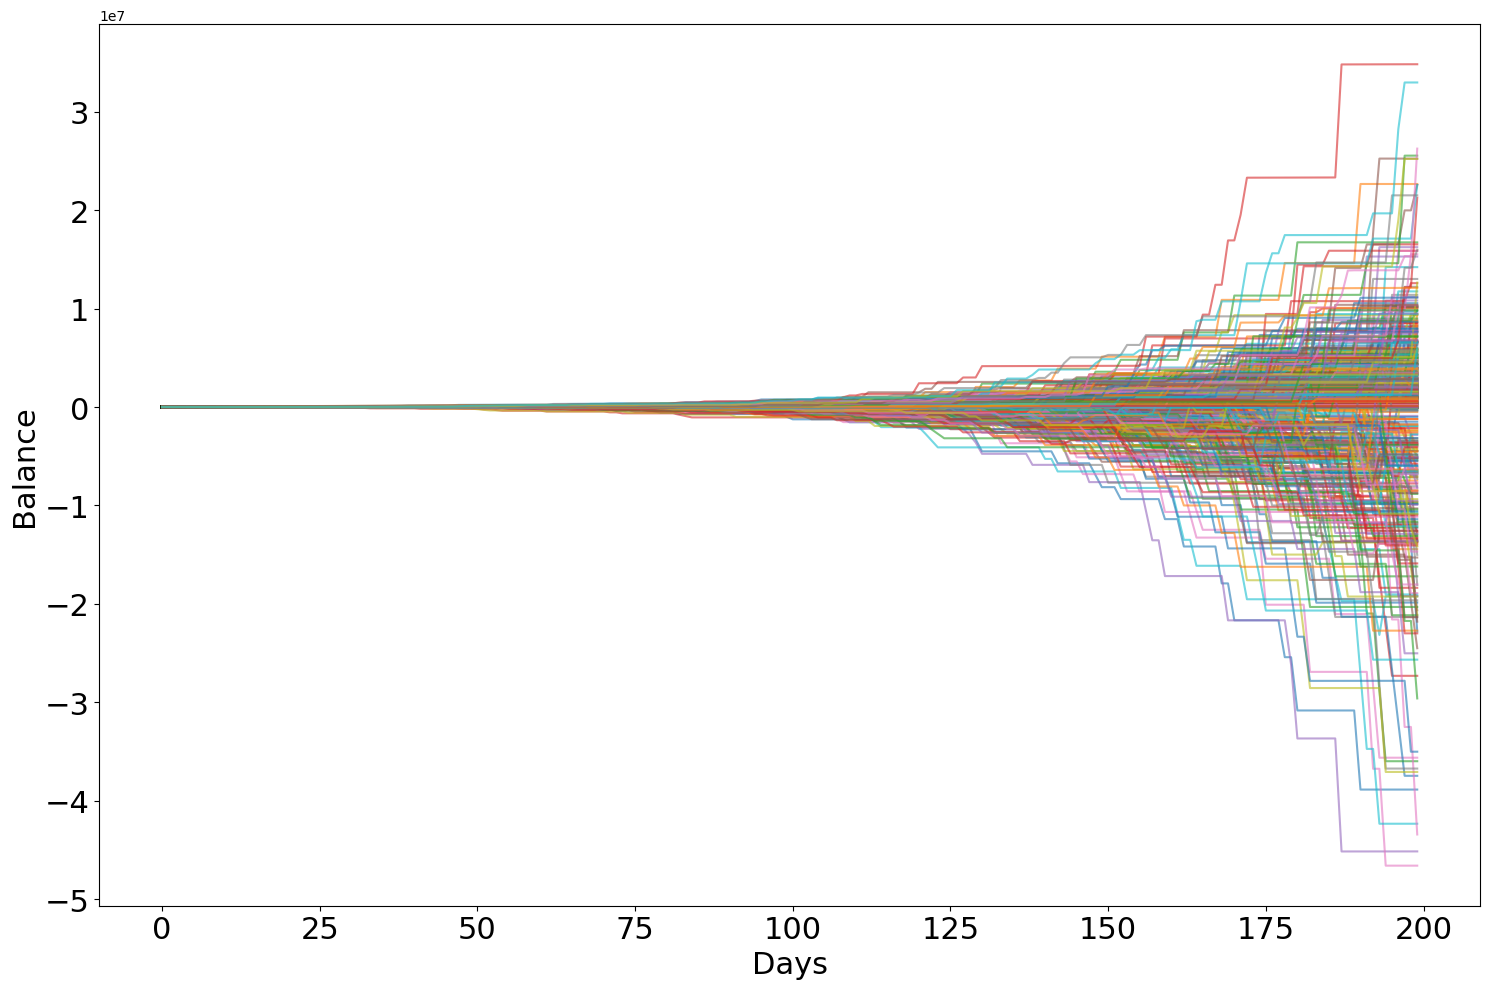

In [10]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

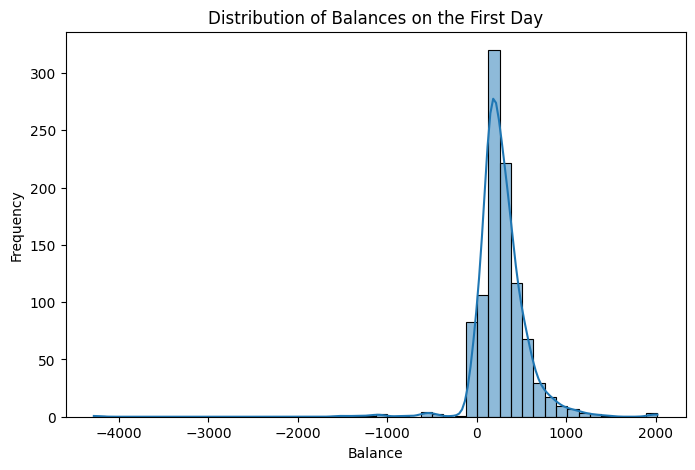

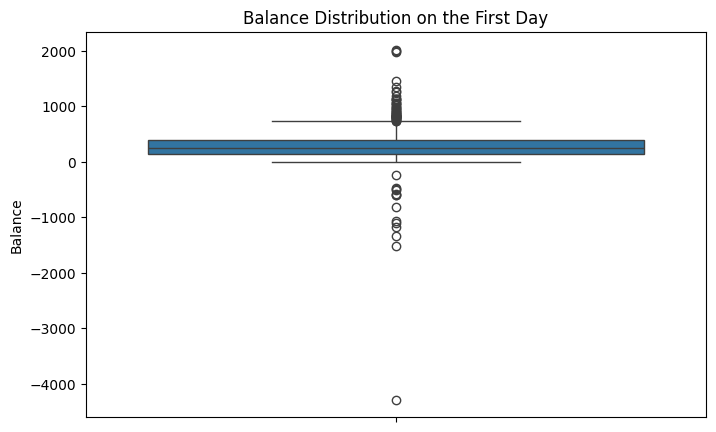

In [10]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

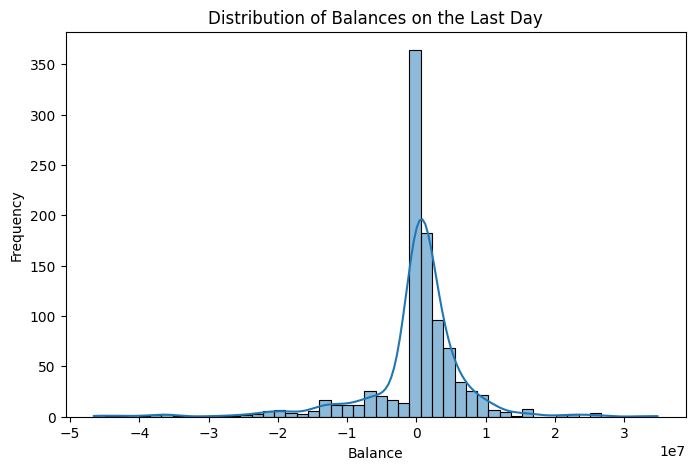

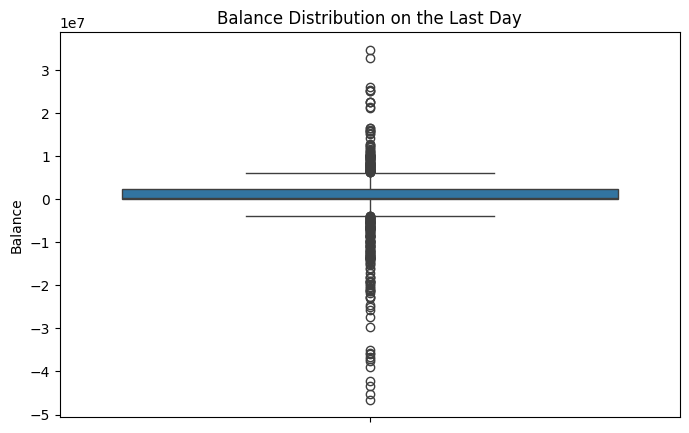

In [11]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

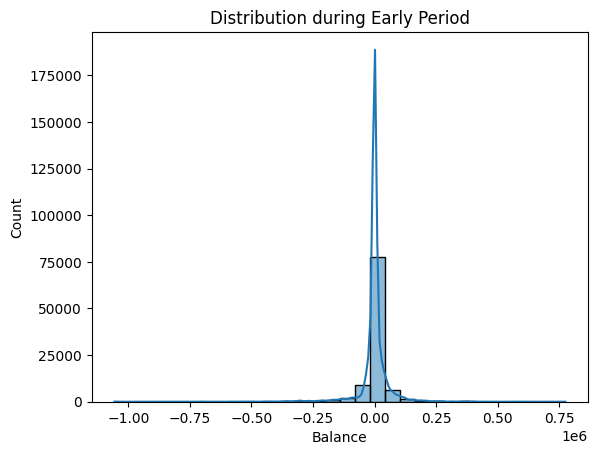

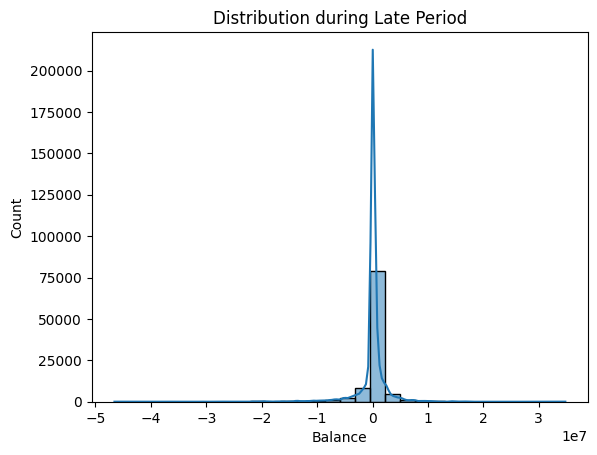

In [12]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

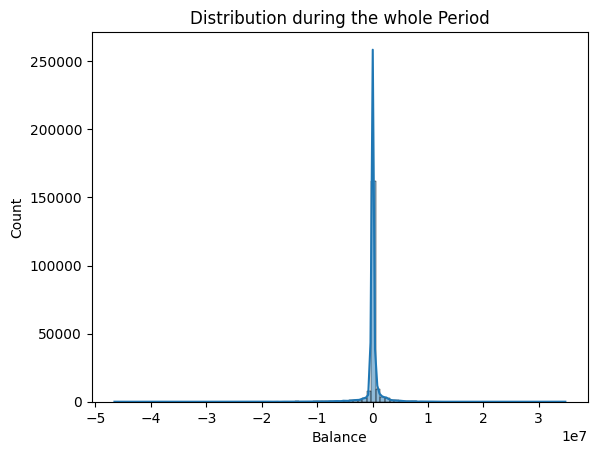

In [13]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

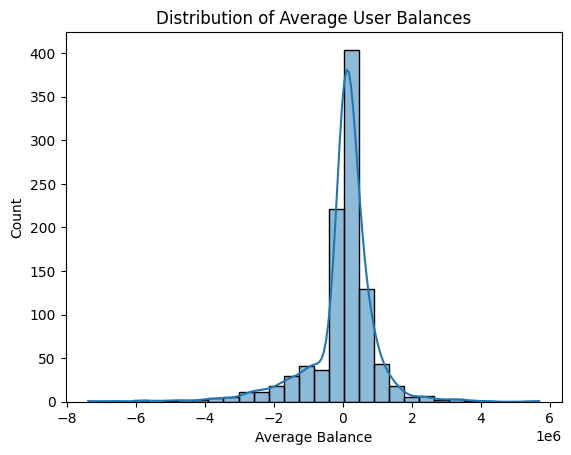

In [14]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Techniques

## CLT

In [15]:
random_users = []

total_account = len(df.columns)

print(f"Total accounts: {total_account}")
random.seed(45)  # Fixes randomness for consistent results

for _ in range(900):
    new = False
    while new == False:
        user = random.randint(0, total_account - 1)
        if user not in random_users:
            new = True
            random_users.append(user)

print(f"Number of extracted random accounts: {len(random_users)}")

Total accounts: 1000
Number of extracted random accounts: 900


In [16]:
days = len(balances) # num of days
weeks = len(balances)//7 # num of weeks
rest = len(balances)%7 # remaining days

In [17]:
clt_distribution = []

# in order to appy CLT -> every week take the mean of the selected users' balances
for i in range(weeks):
    week_data = []
    week_balances = df.iloc[i*7]
    # print(week_balances.name)

    for user in random_users:
    # for user in range(len(df.columns)): -> se prendo tutti gli utenti
        # print(user)
        # print(week_balances[user])
        week_data.append(week_balances[user])
    
    mean = np.mean(week_data)
    clt_distribution.append(round(mean, 2))

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_12618/536784648.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  week_data.append(week_balances[user])


In [18]:
clt_distribution = [float(np_float) for np_float in clt_distribution]
clt_distribution

[279.46,
 296.44,
 293.13,
 275.53,
 266.44,
 362.6,
 256.74,
 66.72,
 -108.07,
 -126.9,
 -435.21,
 -351.93,
 -591.1,
 -415.3,
 -727.24,
 -1565.77,
 -2040.35,
 -4680.0,
 -5457.32,
 -9931.91,
 -10314.64,
 -12683.74,
 -9430.23,
 -10465.36,
 -11041.11,
 -29415.99,
 -60414.41,
 -87152.42]

<function matplotlib.pyplot.show(close=None, block=None)>

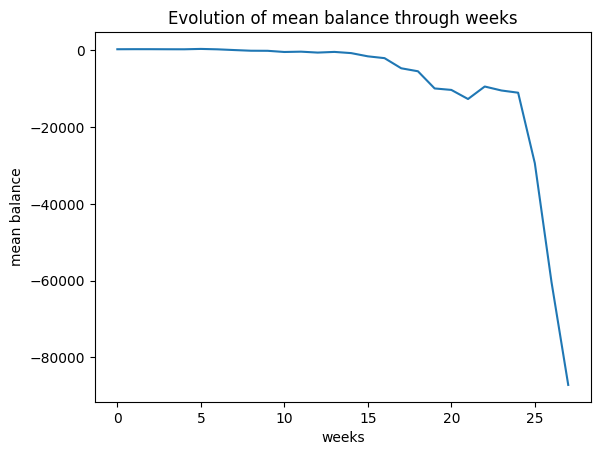

In [19]:
plt.plot(range(weeks), clt_distribution)
plt.xlabel("weeks")
plt.ylabel("mean balance")
plt.title("Evolution of mean balance through weeks")
plt.show

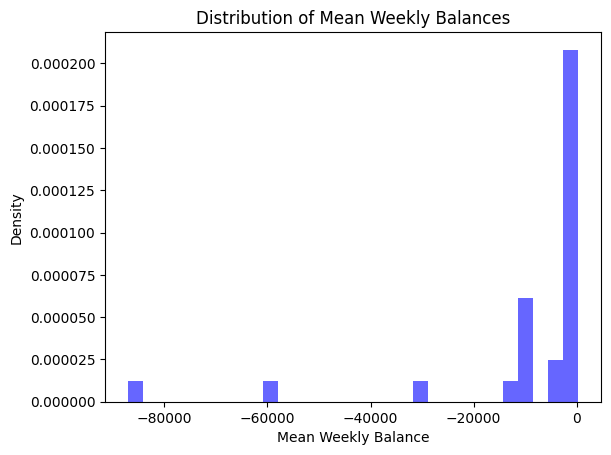

In [20]:
# Histogram to visually inspect the shape of the distribution of the mean balance during weeks
# X axis -> offset +7.469e4 from 74.690 to 74.696
plt.hist(clt_distribution, bins=30, density=True, alpha=0.6, color='b')
plt.xlabel("Mean Weekly Balance")
plt.ylabel("Density")
plt.title("Distribution of Mean Weekly Balances")
plt.show()

In [21]:
# If p > 0.05, the data is likely normally distributed
# If stat -> 1 the data is likely normally distributed
def ks_test(distribution):
    mu = np.mean(distribution)
    std = np.std(distribution)
    ks_stat, ks_p = stats.kstest(distribution, 'norm', args=(mu, std))

    print(f"K-S Test: Statistic={ks_stat:.4f}, p-value={ks_p:.4g}")

    if ks_p < 0.05:
        print("Data is likely NOT normal.")
    else:
        print("Data is likely normal.")

In [22]:
ks_test(clt_distribution)


K-S Test: Statistic=0.3199, p-value=0.004768
Data is likely NOT normal.


In [23]:
clt_mean = np.mean(clt_distribution)
clt_std = np.std(clt_distribution)

# Generate synthetic data using the CLT mean & std
clt_synthetic_data = np.random.normal(loc=clt_mean, scale=clt_std, size=(days, total_account))

# Convert to DataFrame
df_clt = pd.DataFrame(clt_synthetic_data)

In [24]:
values_df_clt = df_clt.values.flatten()

ks_test(values_df_clt)

K-S Test: Statistic=0.0016, p-value=0.6598
Data is likely normal.


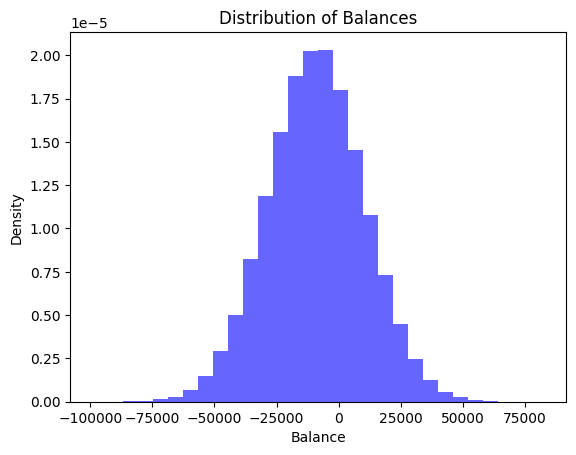

In [25]:
plt.hist(values_df_clt, bins=30, density=True, alpha=0.6, color='b')
plt.xlabel("Balance")
plt.ylabel("Density")
plt.title("Distribution of Balances")
plt.show()

## Log -> negative numbers

In [26]:
df_log = np.log(df + 1e9) # to avoid negative numbers
# df_log = np.log(df)

In [27]:
# Flatten the DataFrame values into a single array
values_df_log = df_log.values.flatten()

nan_count = np.isnan(values_df_log).sum()
print("Number of NaN values:", nan_count)

Number of NaN values: 0


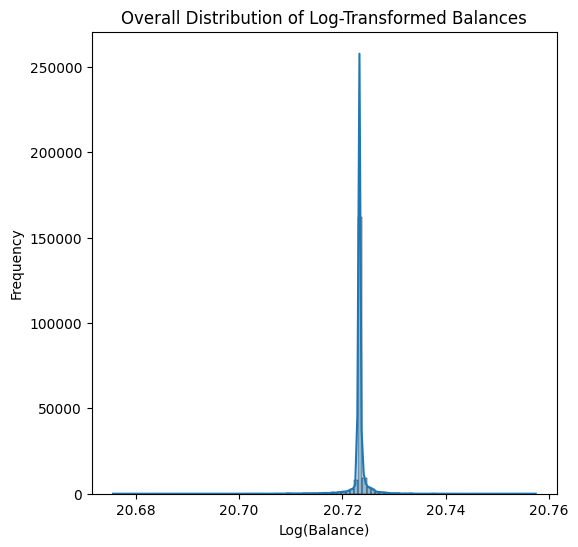

In [28]:
plt.figure(figsize=(6, 6))
sns.histplot(values_df_log, kde=True, bins=100, edgecolor='black')
plt.title("Overall Distribution of Log-Transformed Balances")
plt.xlabel("Log(Balance)")
plt.ylabel("Frequency")
plt.show()

Can't be computed due to negative numbers

In [29]:
ks_test(values_df_log)

K-S Test: Statistic=0.3785, p-value=0
Data is likely NOT normal.


## Wold

In [30]:
# Difference with previous row
df_w = df.diff().dropna()  # drop the first row which will be NaN

values_df_w = df_w.values.flatten()

# Remove NaN values (from the first differencing step)
values_df_w = values_df_w[~np.isnan(values_df_w)]

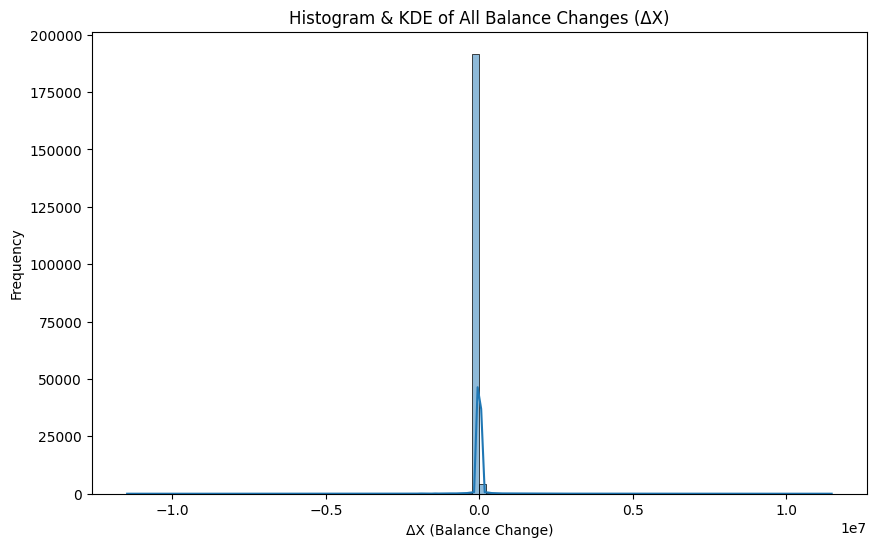

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(values_df_w, kde=True, bins=100, edgecolor='black')
plt.title("Histogram & KDE of All Balance Changes (ΔX)")
plt.xlabel("ΔX (Balance Change)")
plt.ylabel("Frequency")
plt.show()

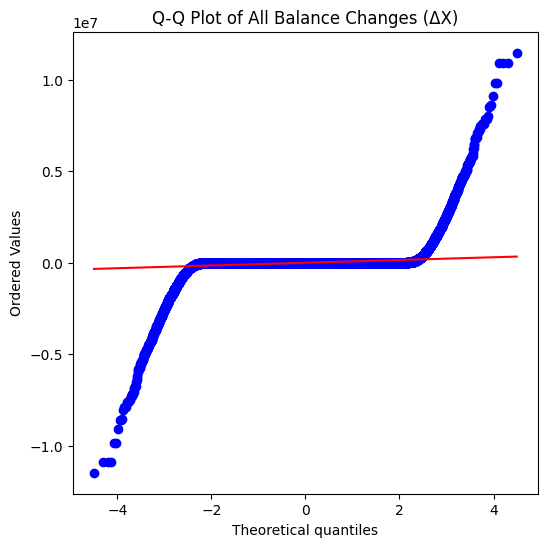

In [32]:
plt.figure(figsize=(6, 6))
stats.probplot(values_df_w, dist="norm", plot=plt)
plt.title("Q-Q Plot of All Balance Changes (ΔX)")
plt.show()

In [33]:
ks_test(values_df_w)

K-S Test: Statistic=0.4773, p-value=0
Data is likely NOT normal.


## Geometric brownian -> negative numbers

In [34]:
df_gmb = np.log((df / df.shift(1)) + 1e9) # Compute r_t = log(X_t / X_{t-1}) for each user
df_gmb = df_gmb.dropna()  # Remove the first row which will be NaN

# Flatten the DataFrame into a 1D array
values_df_gmb = df_gmb.values.flatten()

# Remove any potential NaN values
values_df_gmb = values_df_gmb[~np.isnan(values_df_gmb)]

/opt/anaconda3/envs/bank/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


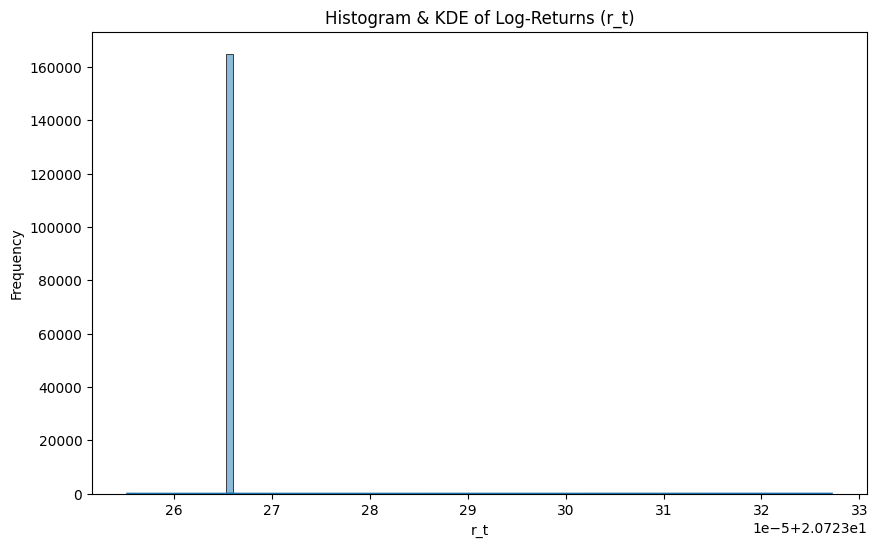

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(values_df_gmb, kde=True, bins=100, edgecolor='black')
plt.title("Histogram & KDE of Log-Returns (r_t)")
plt.xlabel("r_t")
plt.ylabel("Frequency")
plt.show()

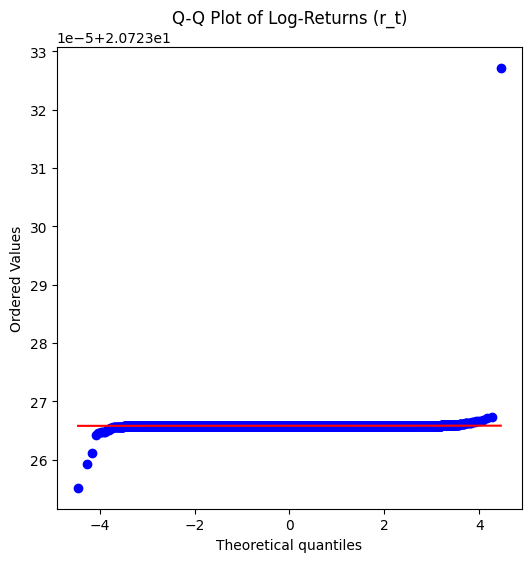

In [36]:
plt.figure(figsize=(6, 6))
stats.probplot(values_df_gmb, dist="norm", plot=plt)
plt.title("Q-Q Plot of Log-Returns (r_t)")
plt.show()

In [37]:
ks_test(values_df_gmb)

K-S Test: Statistic=0.4912, p-value=0
Data is likely NOT normal.


# Squic

In [39]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,184.44,184.44,184.44,184.44,184.44,202.04,202.04,202.04,...,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92,-2967.92
1,175.80,175.80,175.80,175.80,175.80,175.80,175.80,175.80,0.00,0.00,...,241430.83,241430.83,241430.83,5052903.33,5052903.33,5052727.53,5052727.53,5052727.53,5052727.53,5052727.53
2,142.06,142.06,142.06,142.06,142.06,142.06,142.06,0.01,0.01,-142.04,...,-2556.89,-2556.89,-2556.89,-2556.89,-2556.89,-2556.89,-2556.89,-2698.94,-2840.99,-2840.99
3,0.01,-125.87,-251.75,-251.75,-251.75,-251.75,-251.75,-251.75,-251.75,-251.75,...,3005751.70,3005751.70,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82,3005625.82
4,151.13,151.13,151.13,151.13,151.13,151.13,151.13,0.01,0.01,0.01,...,-2720.15,-2720.15,-2720.15,-2720.15,-2720.15,-2720.15,-2720.15,-2871.27,-2871.27,-2871.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,505.04,863.83,883.60,921.38,1098.21,1139.64,1311.64,1919.17,2073.19,3817.23,...,10374460.88,10374829.70,10374866.98,10374927.44,10375104.27,10375104.27,10375317.70,10375612.51,10375776.06,10375785.59
996,232.48,277.24,304.16,131.35,618.02,686.25,948.89,1206.46,1213.77,1826.03,...,13882827.42,13882857.49,13882196.31,13882698.98,13883166.22,13883185.18,13883494.04,15319097.36,15319154.74,26236114.00
997,433.74,697.62,1307.15,1516.45,1903.67,2564.86,2934.70,1746.54,1792.12,1792.12,...,14679222.71,14679458.67,14680068.20,14678721.53,14679108.36,21491333.73,21491715.32,21492112.69,21492140.61,21492185.90
998,733.72,1380.83,1805.36,2628.90,3546.84,3989.42,4006.79,4216.60,4265.58,4590.76,...,14277174.59,14276268.66,14275176.64,14275987.01,14276892.80,14277318.48,18981127.13,25189362.25,25187826.64,25188141.01


In [40]:
ROWS = len(df.iloc[0])

In [41]:
l = [9e-1, 8e-1, 7e-1, 5e-1, 2e-1, 1e-1]

## Squic DF

In [42]:
rho_df = {}

In [43]:
Y = df.T.to_numpy()  # Transpose to get shape (users, days)

In [44]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    rho_df[rho], end_time = compute_squic(Y, rho)
    end_time = round(end_time, 2)
    print(f"time required: {end_time} seconds")

    nonz, nonz_r = count_nnz(rho_df[rho], ROWS)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(end_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        # sparsity_pattern(rho_df[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        # sparsity_pattern(rho_df[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_df[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")

data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    21 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.90e-02 nnz(S)/p=1.00e+03
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=6.10e-01 nnz(X,W)/p=[1.00e+03 1.00e+00] 

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
time required: 0.

### Squic DF Norm

In [45]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [46]:
rho_df = {}

In [47]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    rho_df[rho], end_time = compute_squic(Y_new, rho)
    end_time = round(end_time, 2)
    print(f"time required: {end_time} seconds")

    nonz, nonz_r = count_nnz(rho_df[rho], ROWS)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(end_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(rho_df[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        sparsity_pattern(rho_df[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_df[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")

data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

## Squic-fit

2 consecutive SQUIC calls, with the 2nd one using as a bias negative offdiagonals of the first matrix estimation. Then we keep only the structure and the weights of only the negative offdiagonal entries (from the 2nd precision matrix estimation).

In [57]:
Y = df.T.to_numpy()  # Convert to (users, days)

In [58]:
l = [9e-1, 8e-1, 7e-1, 5e-1, 2e-1, 1e-1]

In [59]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [ ]:
norm_dict = {}

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=8.84e-03 nnz(S)/p=1.51e+02
* iter=1 time=3.72e-02 obj=1.83e+03 |delta(obj)|/obj=4.53e-01 nnz(X,L,W)/p=[1.51e+02 1.36e+02 1.00e+00] lns_iter=5 
* iter=2 time=9.30e-02 obj=1.83e+03 |delta(obj)|/obj=1.39e-03 nnz(X,L,W)/p=[1.51e+02 1.36e+02 9.43e+01] lns_iter=9 
* iter=3 time=1.40e+00 obj=1.75e+03 |delta(obj)|/o

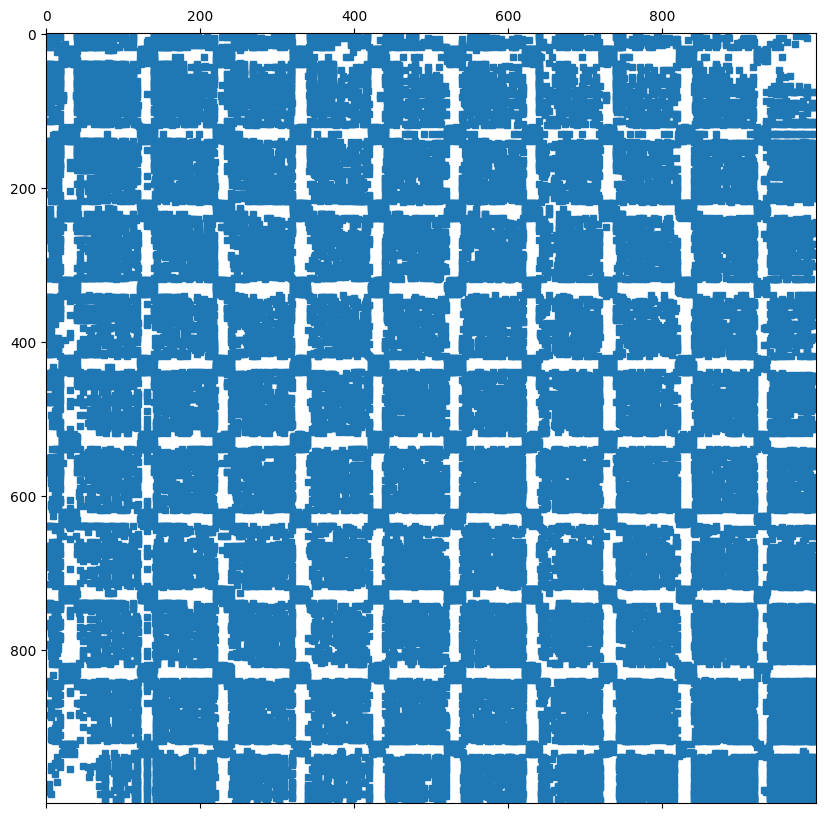

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      8.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.23e-02 nnz(S)/p=3.76e+02
* iter=1 time=9.08e-02 obj=1.73e+03 |delta(obj)|/obj=4.22e-01 nnz(X,L,W)/p=[3.76e+02 3.78e+02 1.00e+00] lns_iter=7 
* iter=2 time=3.08e-01 obj=1.71e+03 |delta(obj)|/obj=9.48e-03 nnz(X,L,W)/p=[3.76e+02 3.78e+02 3.21e+02] lns_iter=9 
* iter=3 time=1.60e+01 obj=1.66e+03 |delta(obj)|/o

In [ ]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    norm_dict[rho], end_time = squic_fit(Y_new,rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(norm_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

data_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]